In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/exchange_rate.csv')
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [4]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [6]:
df.shape

(7588, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [8]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df.head()

,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


In [9]:
df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [10]:
df.shape

(7588, 1)

In [11]:
df.isnull().sum()

,0
Ex_rate,0


In [12]:
df.duplicated().sum()

np.int64(2258)

In [13]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


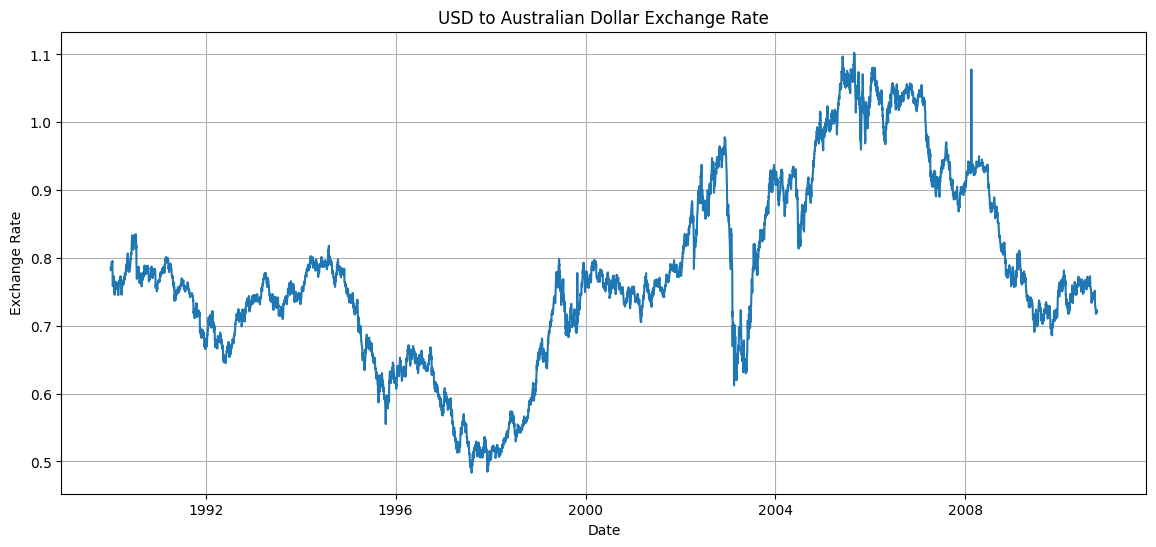

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df['Ex_rate'])

plt.title('USD to Australian Dollar Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)

plt.show()

In [15]:
print("Missing values:", df['Ex_rate'].isnull().sum())

Missing values: 0


In [16]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Ex_rate'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


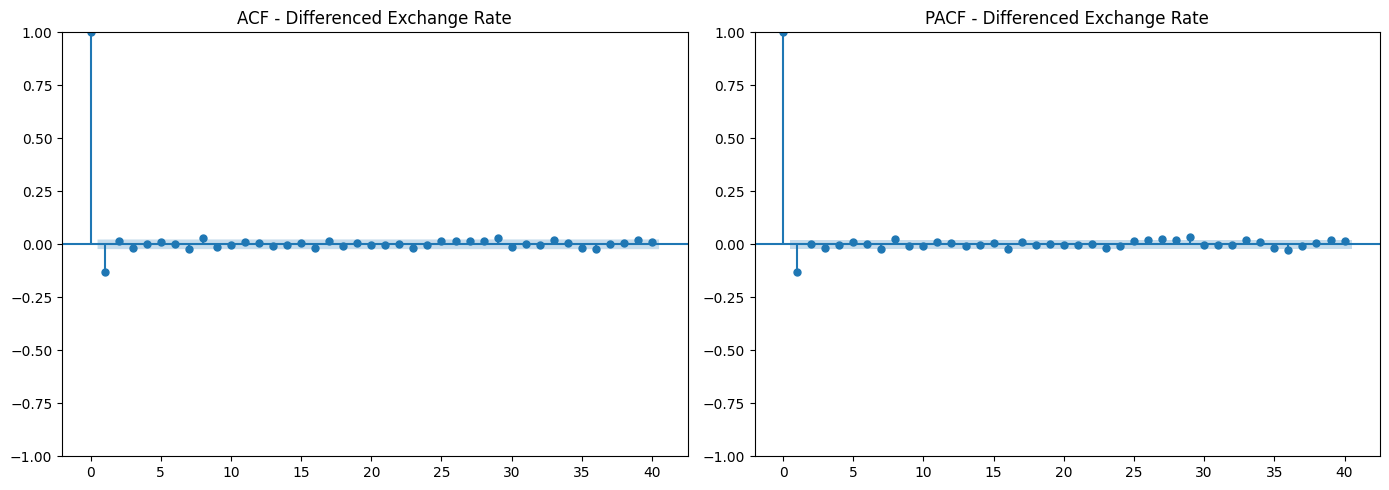

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df_diff = df['Ex_rate'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF - Differenced Exchange Rate')

plot_pacf(df_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Differenced Exchange Rate')

plt.tight_layout()
plt.show()

In [19]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,1,1)
arima_model = ARIMA(df['Ex_rate'], order=(1, 1, 1))

arima_result = arima_model.fit()

print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Mon, 17 Aug 2026   AIC                         -56102.322
Time:                        18:27:04   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

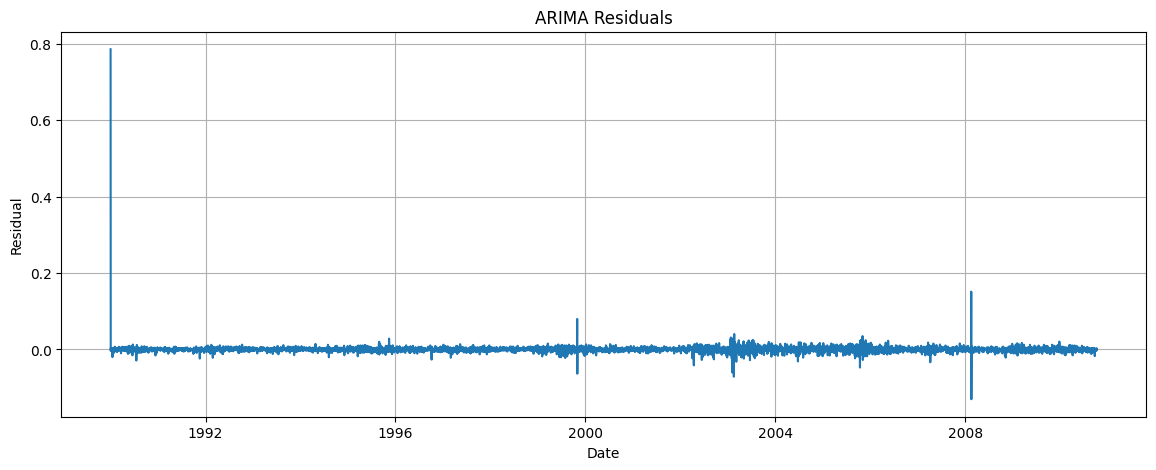

In [20]:
# Residual diagnostics

residuals = arima_result.resid

plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title('ARIMA Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

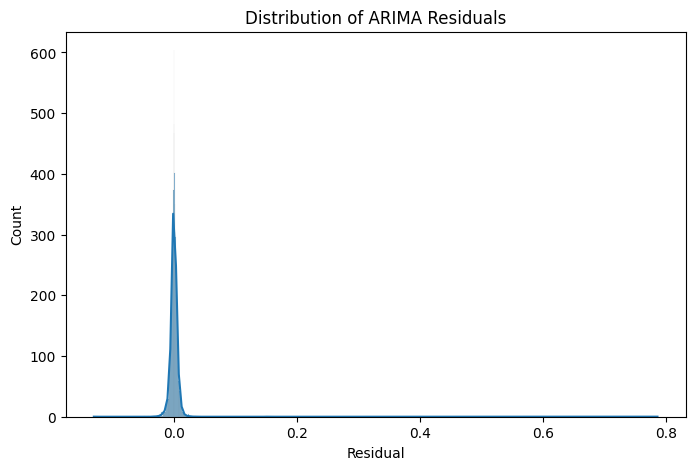

In [21]:
# Residual distribution

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('Distribution of ARIMA Residuals')
plt.xlabel('Residual')
plt.show()

In [22]:
# Chronological train-test split
# Use the first 80% for training and the remaining 20% for testing

train_size = int(len(df) * 0.8)

train = df['Ex_rate'].iloc[:train_size]
test = df['Ex_rate'].iloc[train_size:]

print("Training size:", len(train))
print("Testing size:", len(test))

Training size: 6070
Testing size: 1518


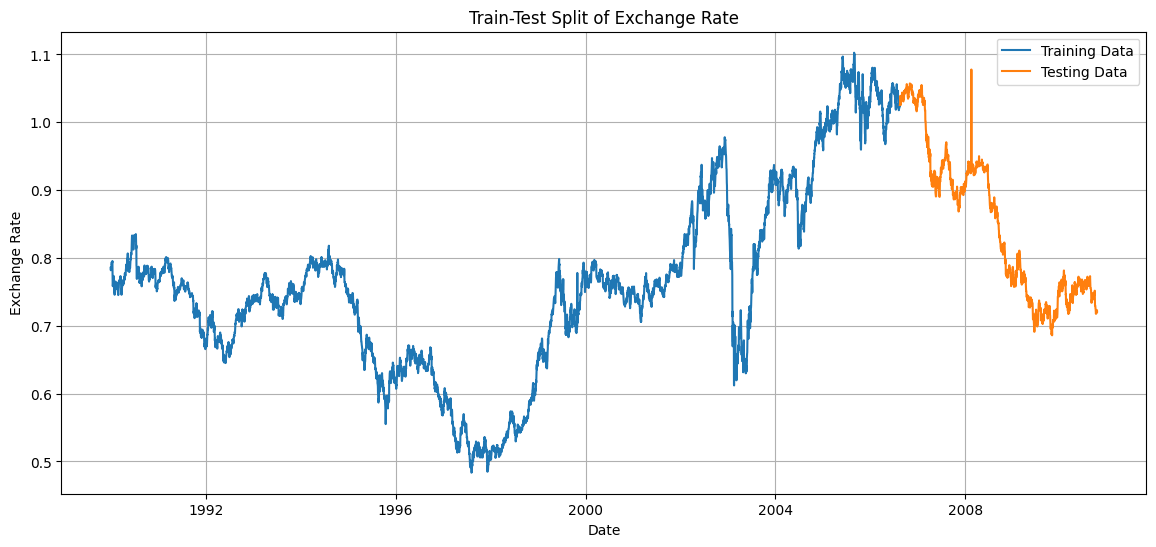

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Testing Data')

plt.title('Train-Test Split of Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

In [24]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,1,1) on training data only
arima_train_model = ARIMA(train, order=(1, 1, 1))
arima_train_result = arima_train_model.fit()

# Forecast for the entire test period
arima_forecast = arima_train_result.forecast(steps=len(test))

print(arima_forecast.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
Freq: D, Name: predicted_mean, dtype: float64


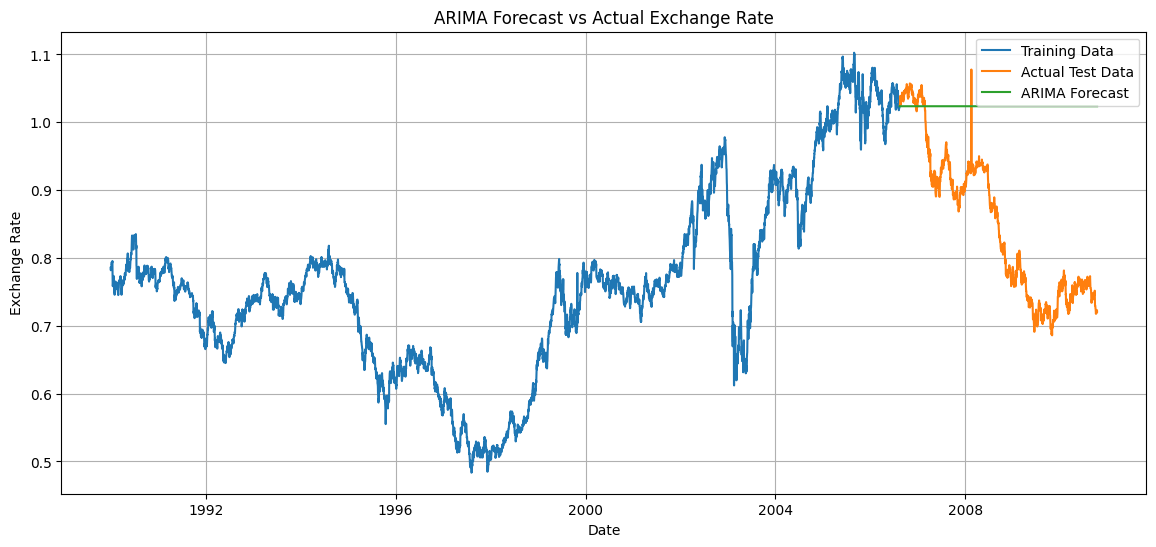

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')

plt.title('ARIMA Forecast vs Actual Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ARIMA evaluation metrics

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

print("ARIMA Performance:")
print("MAE  :", arima_mae)
print("RMSE :", arima_rmse)
print("MAPE :", arima_mape, "%")

ARIMA Performance:
MAE  : 0.17770970449121345
RMSE : 0.2054366965966928
MAPE : 22.797966173811552 %


In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Exponential Smoothing on training data
es_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

es_result = es_model.fit()

# Forecast the test period
es_forecast = es_result.forecast(len(test))

print(es_forecast.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
Freq: D, dtype: float64


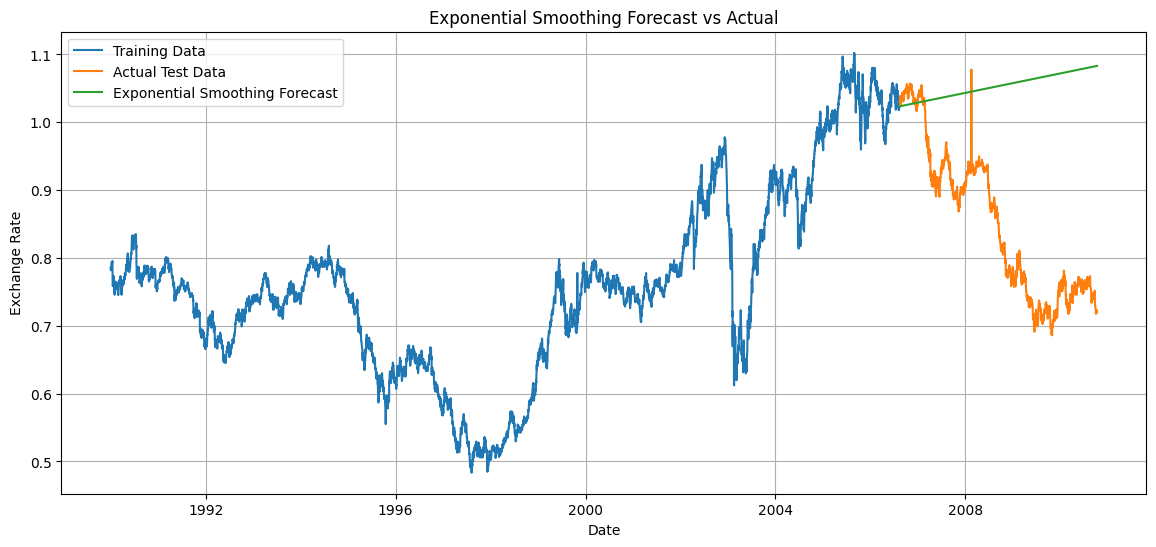

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, es_forecast, label='Exponential Smoothing Forecast')

plt.title('Exponential Smoothing Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

In [29]:
# Exponential Smoothing evaluation metrics

es_mae = mean_absolute_error(test, es_forecast)
es_rmse = np.sqrt(mean_squared_error(test, es_forecast))
es_mape = np.mean(np.abs((test - es_forecast) / test)) * 100

print("Exponential Smoothing Performance:")
print("MAE  :", es_mae)
print("RMSE :", es_rmse)
print("MAPE :", es_mape, "%")

Exponential Smoothing Performance:
MAE  : 0.20659619114093827
RMSE : 0.23910443161792286
MAPE : 26.50866379878783 %


In [30]:
# Compare ARIMA and Exponential Smoothing

comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [arima_mae, es_mae],
    'RMSE': [arima_rmse, es_rmse],
    'MAPE': [arima_mape, es_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


In [31]:
# Identify the best model based on RMSE

best_model = comparison.loc[comparison['RMSE'].idxmin()]

print("Best Model based on RMSE:")
print(best_model)

Best Model based on RMSE:
Model        ARIMA
MAE        0.17771
RMSE      0.205437
MAPE     22.797966
Name: 0, dtype: object


In [32]:

# Final Conclusion

print("""
Conclusion:

ARIMA and Exponential Smoothing were applied to forecast the exchange rate.

The models were evaluated using MAE, RMSE, and MAPE.
Lower values of these metrics indicate better forecasting performance.

The model with the lower RMSE provides the better forecasting performance
for this dataset.

ARIMA is useful for capturing autocorrelation and temporal dependencies,
while Exponential Smoothing is effective for capturing level and trend
patterns in time-series data.

The final model selection is based on the observed error metrics.
""")


Conclusion:

ARIMA and Exponential Smoothing were applied to forecast the exchange rate.

The models were evaluated using MAE, RMSE, and MAPE.
Lower values of these metrics indicate better forecasting performance.

The model with the lower RMSE provides the better forecasting performance
for this dataset.

ARIMA is useful for capturing autocorrelation and temporal dependencies,
while Exponential Smoothing is effective for capturing level and trend
patterns in time-series data.

The final model selection is based on the observed error metrics.

